In [1]:
!pip freeze > requirements.txt

In [2]:
!pip install requests


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [4]:
df = pandas.read_csv('https://raw.githubusercontent.com/Uwanga14/netflix_customer_churn/refs/heads/main/netflix_customer_churn.csv')

In [5]:
df.head(5)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [6]:
df.shape

(5000, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory usage: 547.0

In [8]:
df.subscription_type.value_counts()

subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

In [9]:
df.region.value_counts()

region
South America    873
Europe           867
North America    851
Asia             841
Africa           803
Oceania          765
Name: count, dtype: int64

In [10]:
df.device.value_counts()

device
Tablet     1048
Laptop     1006
Mobile     1004
TV          993
Desktop     949
Name: count, dtype: int64

In [11]:
df.payment_method.value_counts()

payment_method
Debit Card     1030
PayPal         1026
Crypto          995
Gift Card       976
Credit Card     973
Name: count, dtype: int64

In [12]:
df.churned.value_counts()

churned
1    2515
0    2485
Name: count, dtype: int64

In [13]:
df.favorite_genre.value_counts()

favorite_genre
Drama          731
Documentary    729
Romance        725
Sci-Fi         720
Horror         713
Action         697
Comedy         685
Name: count, dtype: int64

In [14]:
df.gender.value_counts()

gender
Female    1711
Male      1654
Other     1635
Name: count, dtype: int64

In [15]:
df.describe(include='all')

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
count,5000,5000.000000,5000,5000,5000.000000,5000.000000,5000,5000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000
unique,5000,NaN,3,3,NaN,NaN,6,5,NaN,NaN,5,NaN,NaN,7
top,a9b75100-82a8-427a-a208-72f24052884a,NaN,Female,Premium,NaN,NaN,South America,Tablet,NaN,NaN,Debit Card,NaN,NaN,Drama
freq,1,NaN,1711,1693,NaN,NaN,873,1048,NaN,NaN,1030,NaN,NaN,731
mean,NaN,43.847400,NaN,NaN,11.649450,30.089800,NaN,NaN,13.683400,0.503000,NaN,3.024400,0.874800,NaN
std,NaN,15.501128,NaN,NaN,12.014654,17.536078,NaN,NaN,3.692062,0.500041,NaN,1.415841,2.619824,NaN
min,NaN,18.000000,NaN,NaN,0.010000,0.000000,NaN,NaN,8.990000,0.000000,NaN,1.000000,0.000000,NaN
25%,NaN,30.000000,NaN,NaN,3.337500,15.000000,NaN,NaN,8.990000,0.000000,NaN,2.000000,0.110000,NaN
50%,NaN,44.000000,NaN,NaN,8.000000,30.000000,NaN,NaN,13.990000,1.000000,NaN,3.000000,0.290000,NaN
75%,NaN,58.000000,NaN,NaN,16.030000,45.000000,NaN,NaN,17.990000,1.000000,NaN,4.000000,0.720000,NaN


In [16]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
cat_cols=df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['customer_id', 'gender', 'subscription_type', 'region', 'device',
       'payment_method', 'favorite_genre'],
      dtype='str')
Numerical Variables:
['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'churned', 'number_of_profiles', 'avg_watch_time_per_day']


/tmp/ipykernel_31659/3593389501.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include=['object']).columns


Univariate analyses

age
Skew : 0.01


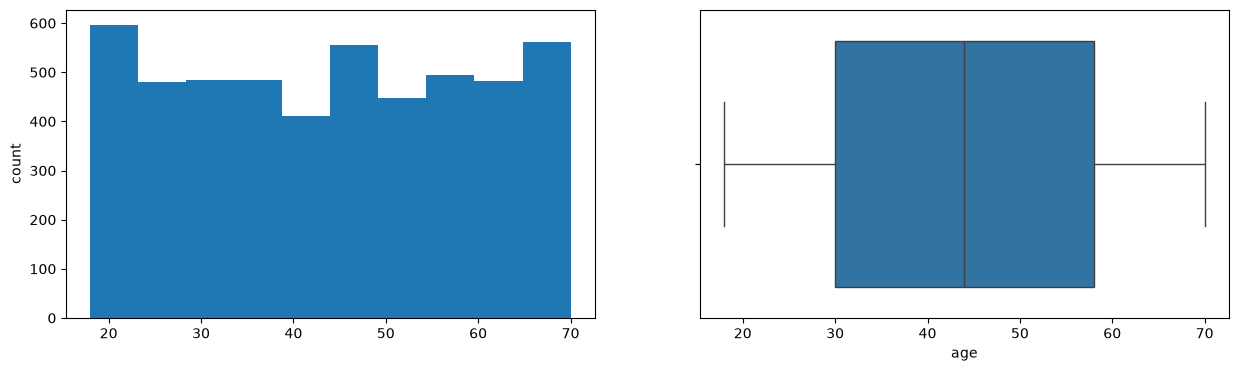

watch_hours
Skew : 2.26


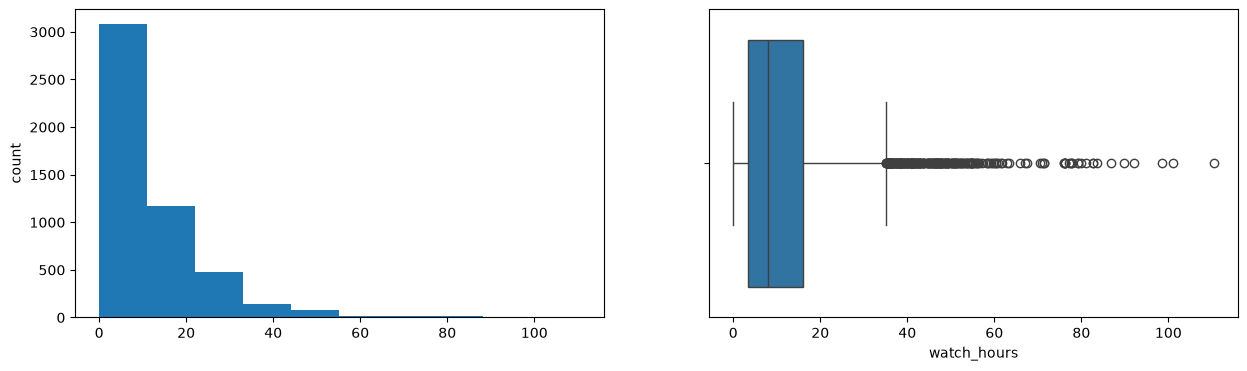

last_login_days
Skew : -0.03


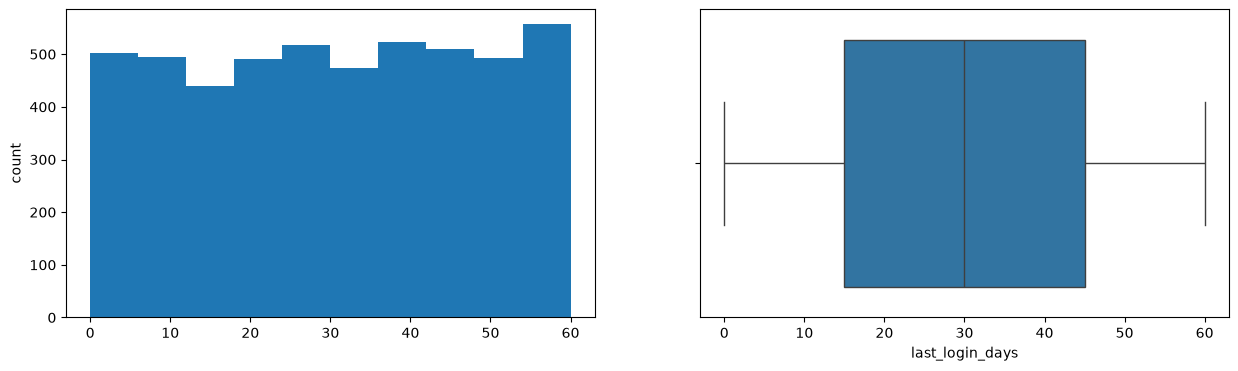

monthly_fee
Skew : -0.14


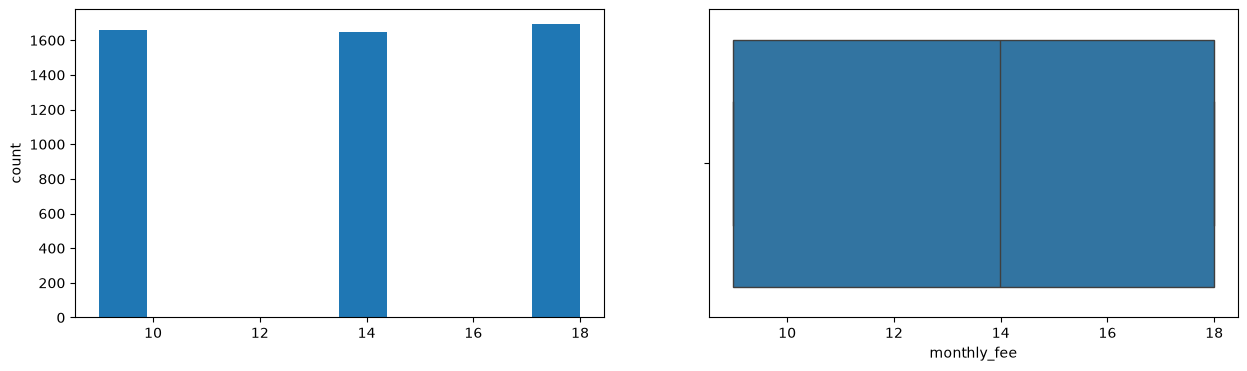

churned
Skew : -0.01


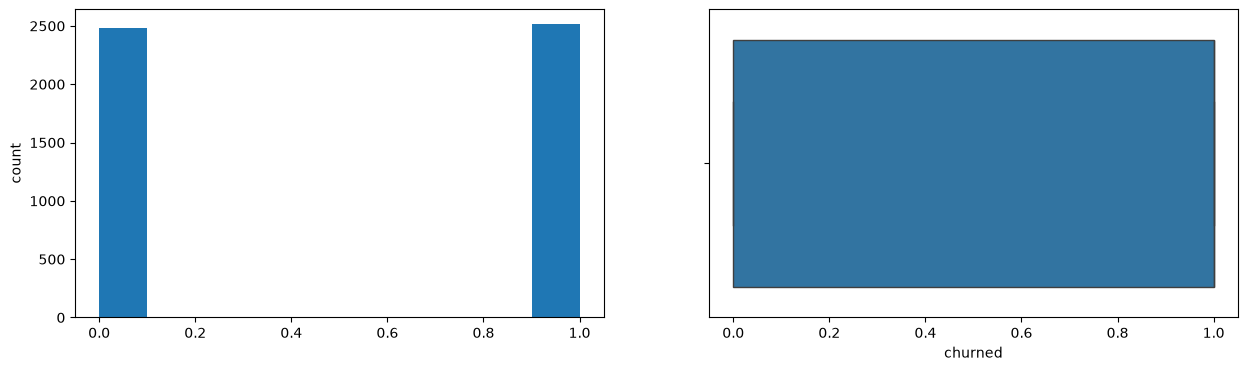

number_of_profiles
Skew : -0.02


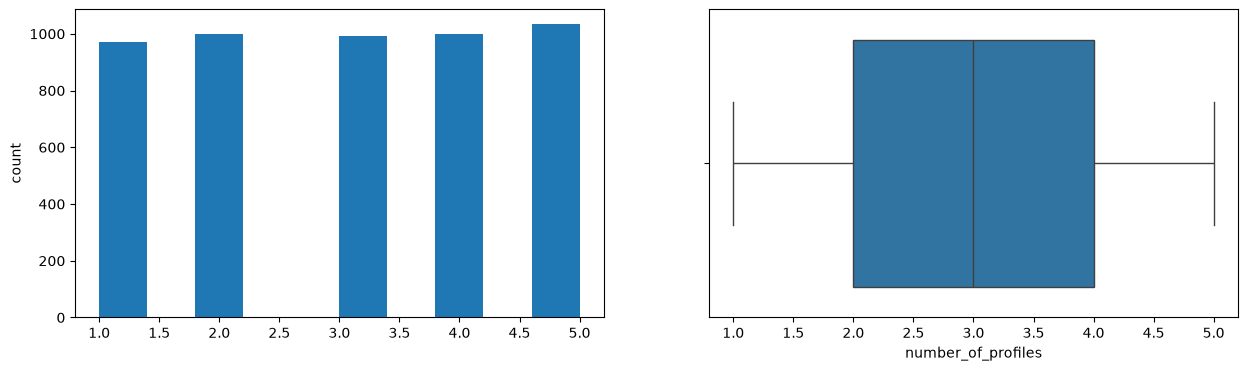

avg_watch_time_per_day
Skew : 15.83


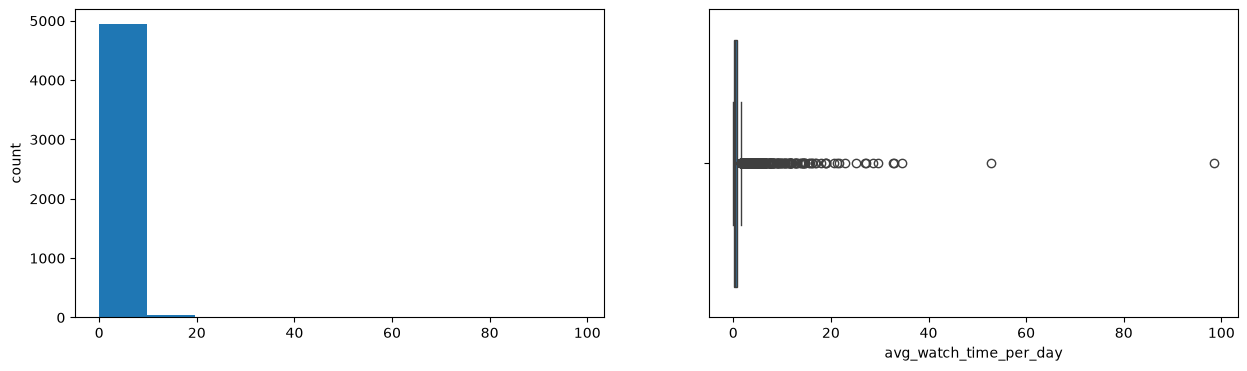

In [19]:
for col in num_cols:
    print(col)
    print('Skew :', round(df[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    df[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.show()
    

<Figure size 1000x600 with 0 Axes>

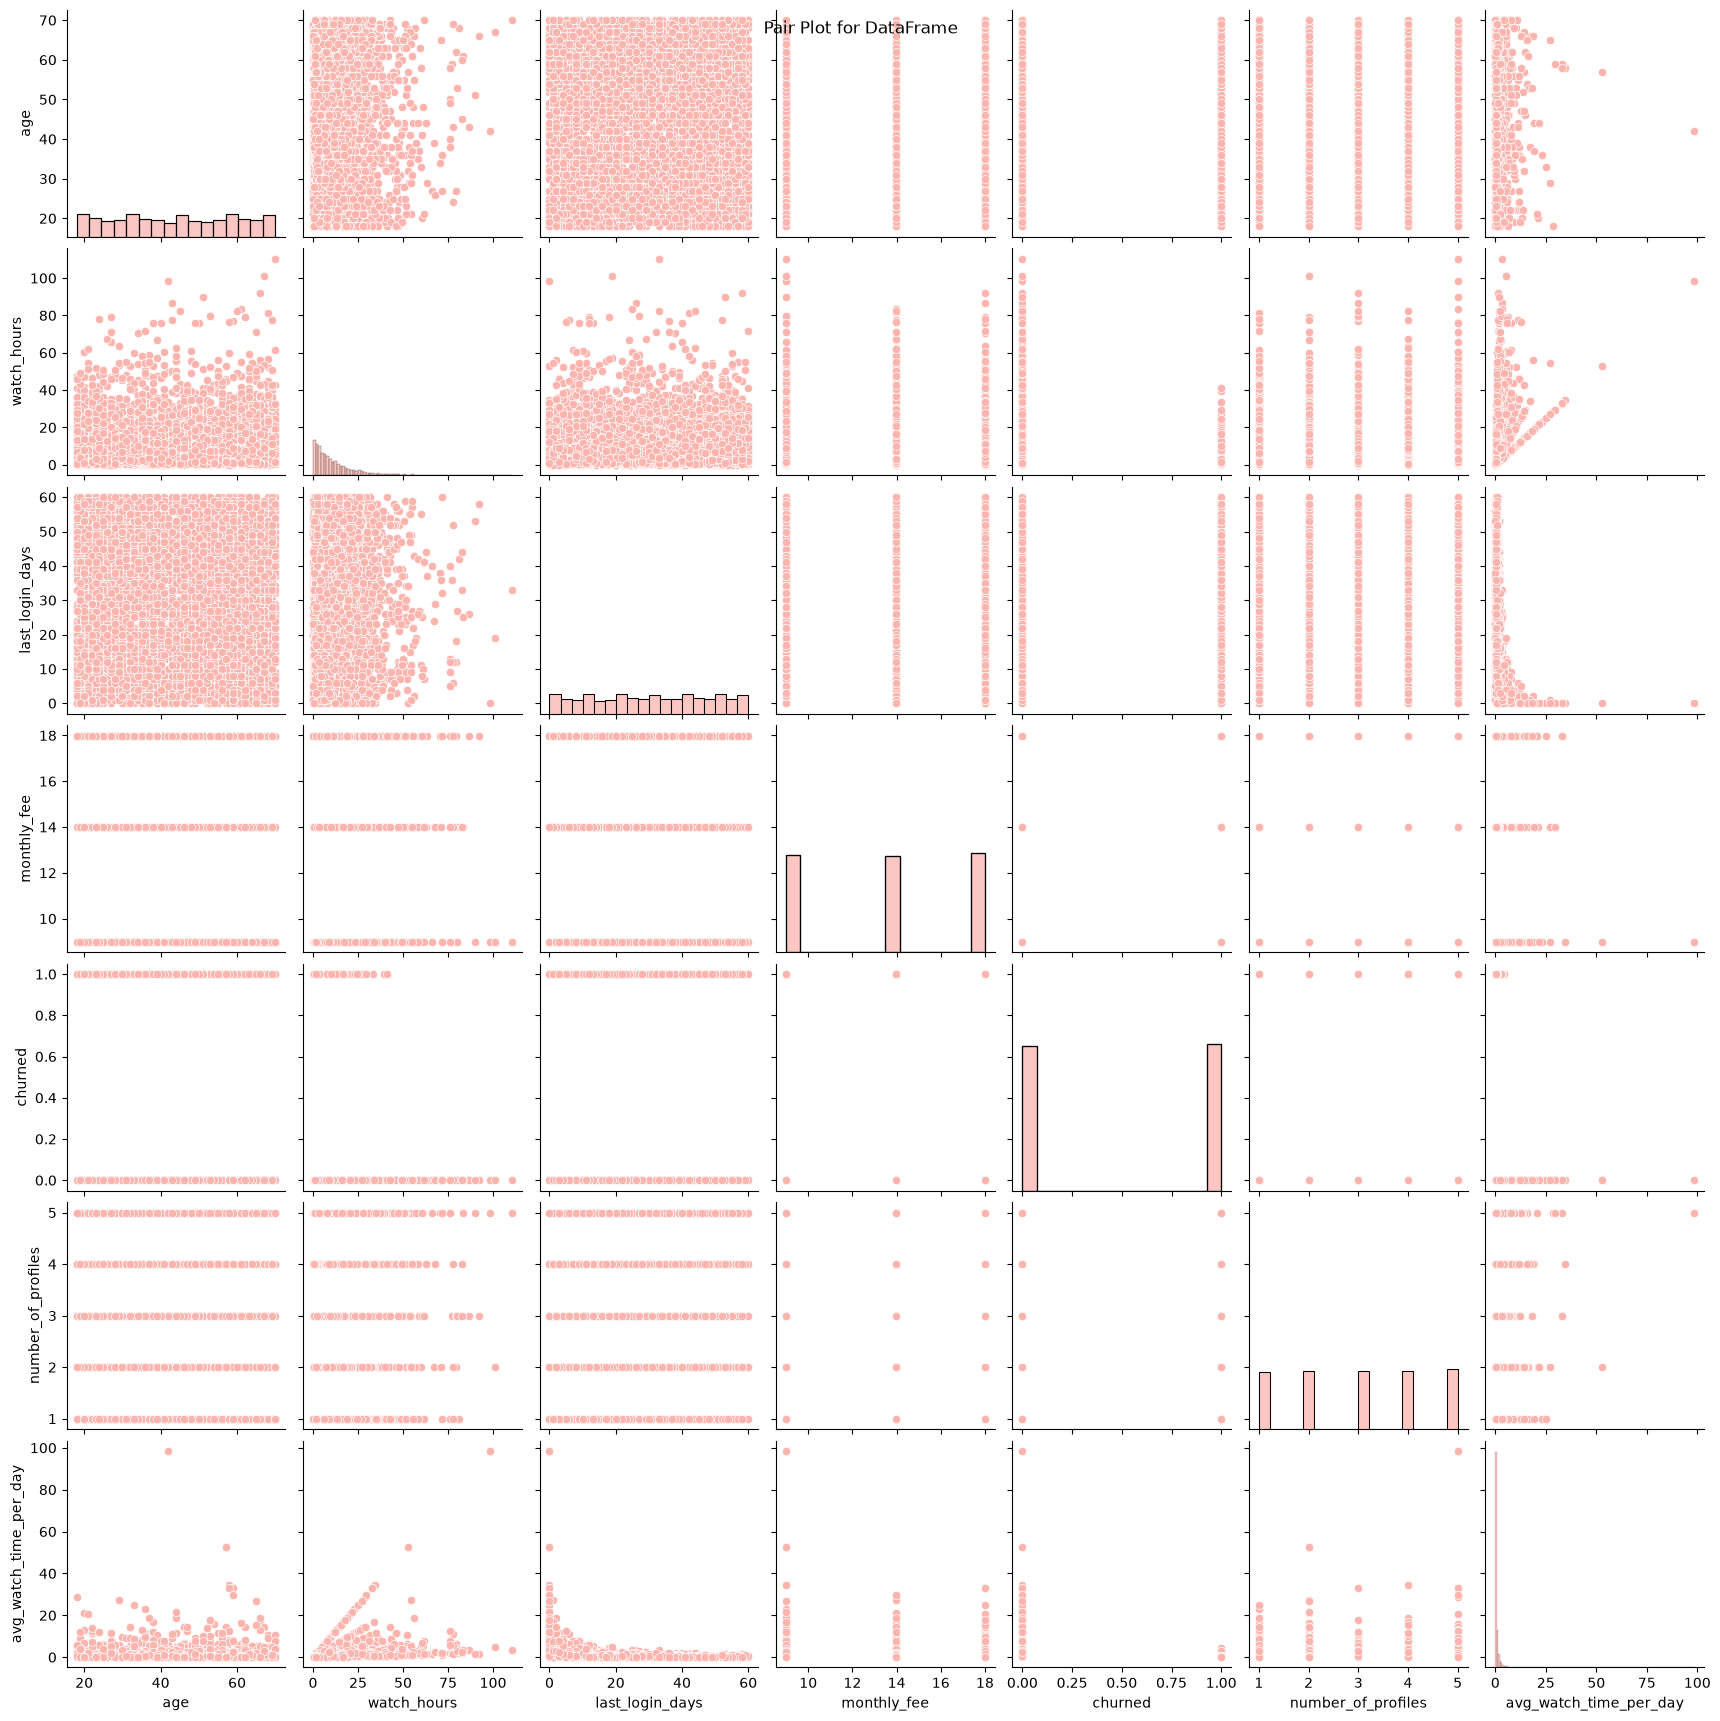

In [20]:
# Set the color palette
sns.set_palette("Pastel1")

# Assuming 'df' is your DataFrame
plt.figure(figsize=(10, 6))

# Using Seaborn to create a pair plot with the specified color palette
sns.pairplot(df)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

In [21]:
df.drop(columns=["customer_id"], inplace=True)

In [22]:
df.head(5)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   gender                  5000 non-null   str    
 2   subscription_type       5000 non-null   str    
 3   watch_hours             5000 non-null   float64
 4   last_login_days         5000 non-null   int64  
 5   region                  5000 non-null   str    
 6   device                  5000 non-null   str    
 7   monthly_fee             5000 non-null   float64
 8   churned                 5000 non-null   int64  
 9   payment_method          5000 non-null   str    
 10  number_of_profiles      5000 non-null   int64  
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(6)
memory usage: 507.9 KB


Converting categorical variables to numerical variables

In [24]:
df = pandas.get_dummies(df, columns=["gender"], dtype=int)

In [25]:
df.head(5)

,age,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,gender_Female,gender_Male,gender_Other
0,51,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,0,0,1
1,47,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,0,0,1
2,27,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,1,0,0
3,53,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,0,0,1
4,56,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,0,0,1


0-Female
1-Male
2-Other

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   subscription_type       5000 non-null   str    
 2   watch_hours             5000 non-null   float64
 3   last_login_days         5000 non-null   int64  
 4   region                  5000 non-null   str    
 5   device                  5000 non-null   str    
 6   monthly_fee             5000 non-null   float64
 7   churned                 5000 non-null   int64  
 8   payment_method          5000 non-null   str    
 9   number_of_profiles      5000 non-null   int64  
 10  avg_watch_time_per_day  5000 non-null   float64
 11  favorite_genre          5000 non-null   str    
 12  gender_Female           5000 non-null   int64  
 13  gender_Male             5000 non-null   int64  
 14  gender_Other            5000 non-null   int64  
dty

In [27]:
df.head(5)

,age,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,gender_Female,gender_Male,gender_Other
0,51,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,0,0,1
1,47,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,0,0,1
2,27,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,1,0,0
3,53,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,0,0,1
4,56,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,0,0,1


In [28]:
df = pandas.get_dummies(df, columns=["subscription_type"], dtype=int)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   watch_hours                 5000 non-null   float64
 2   last_login_days             5000 non-null   int64  
 3   region                      5000 non-null   str    
 4   device                      5000 non-null   str    
 5   monthly_fee                 5000 non-null   float64
 6   churned                     5000 non-null   int64  
 7   payment_method              5000 non-null   str    
 8   number_of_profiles          5000 non-null   int64  
 9   avg_watch_time_per_day      5000 non-null   float64
 10  favorite_genre              5000 non-null   str    
 11  gender_Female               5000 non-null   int64  
 12  gender_Male                 5000 non-null   int64  
 13  gender_Other                5000 non-null   

In [30]:
df = pandas.get_dummies(df, columns=["region"], dtype=int)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   watch_hours                 5000 non-null   float64
 2   last_login_days             5000 non-null   int64  
 3   device                      5000 non-null   str    
 4   monthly_fee                 5000 non-null   float64
 5   churned                     5000 non-null   int64  
 6   payment_method              5000 non-null   str    
 7   number_of_profiles          5000 non-null   int64  
 8   avg_watch_time_per_day      5000 non-null   float64
 9   favorite_genre              5000 non-null   str    
 10  gender_Female               5000 non-null   int64  
 11  gender_Male                 5000 non-null   int64  
 12  gender_Other                5000 non-null   int64  
 13  subscription_type_Basic     5000 non-null   

In [32]:
df = pandas.get_dummies(df, columns=["device"], dtype=int)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   watch_hours                 5000 non-null   float64
 2   last_login_days             5000 non-null   int64  
 3   monthly_fee                 5000 non-null   float64
 4   churned                     5000 non-null   int64  
 5   payment_method              5000 non-null   str    
 6   number_of_profiles          5000 non-null   int64  
 7   avg_watch_time_per_day      5000 non-null   float64
 8   favorite_genre              5000 non-null   str    
 9   gender_Female               5000 non-null   int64  
 10  gender_Male                 5000 non-null   int64  
 11  gender_Other                5000 non-null   int64  
 12  subscription_type_Basic     5000 non-null   int64  
 13  subscription_type_Premium   5000 non-null   

In [34]:
df = pandas.get_dummies(df, columns=["payment_method"], dtype=int)

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   watch_hours                 5000 non-null   float64
 2   last_login_days             5000 non-null   int64  
 3   monthly_fee                 5000 non-null   float64
 4   churned                     5000 non-null   int64  
 5   number_of_profiles          5000 non-null   int64  
 6   avg_watch_time_per_day      5000 non-null   float64
 7   favorite_genre              5000 non-null   str    
 8   gender_Female               5000 non-null   int64  
 9   gender_Male                 5000 non-null   int64  
 10  gender_Other                5000 non-null   int64  
 11  subscription_type_Basic     5000 non-null   int64  
 12  subscription_type_Premium   5000 non-null   int64  
 13  subscription_type_Standard  5000 non-null   

In [36]:
df = pandas.get_dummies(df, columns=["favorite_genre"], dtype=int)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   watch_hours                 5000 non-null   float64
 2   last_login_days             5000 non-null   int64  
 3   monthly_fee                 5000 non-null   float64
 4   churned                     5000 non-null   int64  
 5   number_of_profiles          5000 non-null   int64  
 6   avg_watch_time_per_day      5000 non-null   float64
 7   gender_Female               5000 non-null   int64  
 8   gender_Male                 5000 non-null   int64  
 9   gender_Other                5000 non-null   int64  
 10  subscription_type_Basic     5000 non-null   int64  
 11  subscription_type_Premium   5000 non-null   int64  
 12  subscription_type_Standard  5000 non-null   int64  
 13  region_Africa               5000 non-null   

In [38]:
df.head(5)

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day,gender_Female,gender_Male,gender_Other,...,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal,favorite_genre_Action,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi
0,51,14.73,29,8.99,1,1,0.49,0,0,1,...,0,1,0,1,0,0,0,0,0,0
1,47,0.70,19,13.99,1,5,0.03,0,0,1,...,0,1,0,0,0,0,0,0,0,1
2,27,16.32,10,13.99,0,2,1.48,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,53,4.51,12,17.99,1,2,0.35,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,56,1.89,13,13.99,1,2,0.13,0,0,1,...,0,0,0,1,0,0,0,0,0,0


In [39]:
df['watch_hours'] = df['watch_hours'].astype(int)

In [40]:
df['monthly_fee'] = df['monthly_fee'].astype(int)

In [41]:
df['avg_watch_time_per_day'] = df['avg_watch_time_per_day'].astype(int)

In [42]:
df.head(5)

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day,gender_Female,gender_Male,gender_Other,...,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal,favorite_genre_Action,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi
0,51,14,29,8,1,1,0,0,0,1,...,0,1,0,1,0,0,0,0,0,0
1,47,0,19,13,1,5,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1
2,27,16,10,13,0,2,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,53,4,12,17,1,2,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,56,1,13,13,1,2,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   age                         5000 non-null   int64
 1   watch_hours                 5000 non-null   int64
 2   last_login_days             5000 non-null   int64
 3   monthly_fee                 5000 non-null   int64
 4   churned                     5000 non-null   int64
 5   number_of_profiles          5000 non-null   int64
 6   avg_watch_time_per_day      5000 non-null   int64
 7   gender_Female               5000 non-null   int64
 8   gender_Male                 5000 non-null   int64
 9   gender_Other                5000 non-null   int64
 10  subscription_type_Basic     5000 non-null   int64
 11  subscription_type_Premium   5000 non-null   int64
 12  subscription_type_Standard  5000 non-null   int64
 13  region_Africa               5000 non-null   int64
 14  region_Asia        

In [44]:
df.to_csv('my_dataset.csv', index=False)